In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

from ppdr.utils.dataset import HypersimDataset
from ppdr.utils.geometry import depth_to_point_cloud, edge_mask
from ppdr.utils.reader import HypersimReader
from ppdr.utils.transform import image_tensor2array


In [3]:
reader = HypersimReader("../data/hypersim_test_set")
dataset = HypersimDataset(reader)

image, depth, valid_mask, ncd_to_cam = dataset[0]


In [9]:
mask = edge_mask(image, canny_low=0.01, canny_high=0.1, dilation_px=4)


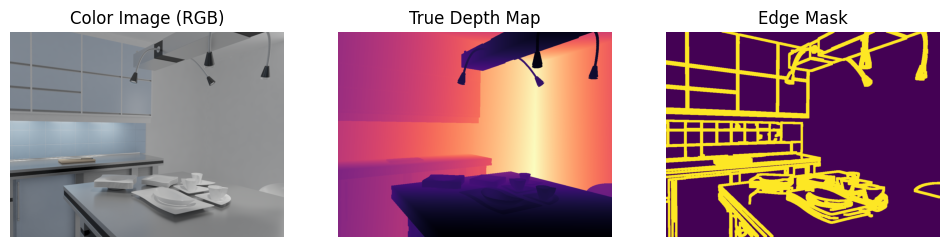

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(image_tensor2array(image))
axes[0].set_title("Color Image (RGB)")
axes[0].axis("off")

axes[1].imshow(depth.numpy(), "magma")
axes[1].set_title("True Depth Map")
axes[1].axis("off")

axes[2].imshow(mask.squeeze().numpy())
axes[2].set_title("Edge Mask")
axes[2].axis("off")


plt.show()

In [6]:
points = depth_to_point_cloud(depth, ncd_to_cam, valid_mask).numpy()
colors = image_tensor2array(image)[valid_mask.numpy()]

print(points.shape)  # (786432, 3)
print(colors.shape)  # (786432, 3)


(786432, 3)
(786432, 3)
